In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

In [ ]:
import pandas as pd

In [ ]:
X , y = fetch_california_housing(return_X_y=True)

In [ ]:
print(X.shape)
print(type(X))

(20640, 8)
<class 'numpy.ndarray'>


In [ ]:
housing = fetch_california_housing()
df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y


In [ ]:
print(df.head())
print(df.describe())
print(df.isnull().sum())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.3333

In [ ]:

correlations = df.corr()
print(correlations['MedHouseVal'].sort_values(ascending=False))

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


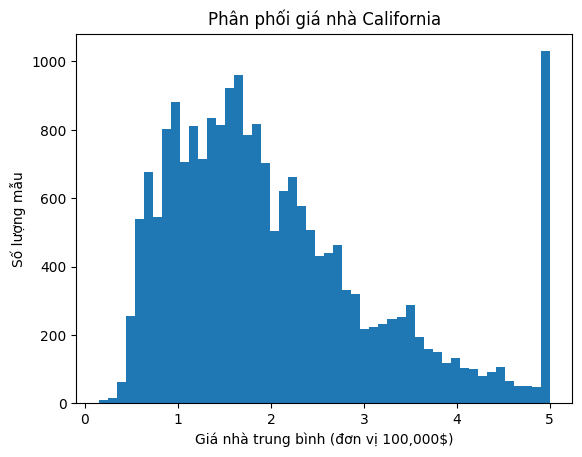

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.xlabel("Giá nhà trung bình (đơn vị 100,000$)")
plt.ylabel("Số lượng mẫu")
plt.title("Phân phối giá nhà California")
plt.show()

In [ ]:
X_train ,X_test, y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
mean_train = X_train.mean(axis = 0)
std_train = X_train.std(axis = 0)

In [ ]:
X_train_norm = (X_train - mean_train)/std_train
X_test_norm = (X_test - mean_train)/std_train

#mean_y_train = y_train.mean()
#std_y_train = y_train.std()
#y_train_norm = (y_train - mean_y_train) / std_y_train

In [ ]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_norm , y_train)

y_predict = sklearn_model.predict(X_test_norm)
#y_predict = y_predict_norm * std_y_train + mean_y_train
sklearn_mse = mean_squared_error(y_test, y_predict)
sklearn_rmse = np.sqrt(sklearn_mse)
sklearn_r2 = r2_score(y_test, y_predict)

print(f"MSE  :      {sklearn_mse:.4f}")
print(f"RMSE : {sklearn_rmse:.4f}")
print(f"R2 Score:                       {sklearn_r2:.4f}")
print(f"Estimated w :\n{sklearn_model.coef_.flatten()}")
print(f"Estimated b : {sklearn_model.intercept_:.4f}")

MSE  :      0.5559
RMSE : 0.7456
R2 Score:                       0.5758
Estimated w :
[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Estimated b : 2.0719
